## Imports and Configuration
**Inputs:** None  
**Outputs:** None  
**Functionality:**  
- Imports `numpy` and `matplotlib.pyplot` for numerical computations and plotting.
- Sets numpy print options for better readability of arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)  # Set print options for numpy arrays

## Stress Calculation Functions
**Inputs:**  
- `r_i`: Inner radius  
- `r_o`: Outer radius  
- `p_i`: Inner pressure  
- `p_o`: Outer pressure  

**Outputs:**  
- Returns hoop stress using Lame's equations (`lame_stress`) and thin-walled approximation (`thin_approx`).

**Functionality:**  
- Defines two functions to calculate hoop stress in thick-walled and thin-walled cylinders.

In [2]:
def lame_stress(r_i, r_o, p_i, p_o):
    """Calculate hoop stresses in a thick-walled cylinder using Lame's equations."""
    A = (p_i * r_i**2 - p_o * r_o**2) / (r_o**2 - r_i**2)
    B = ((p_i - p_o)*(r_i**2 * r_o**2 )) / (r_o**2 - r_i**2)
    return A + B / r_i**2

def thin_approx(r_i, r_o, p_i, p_o):
    """Calculate the hoop stresses in a thin-walled cylinder using approximate equations."""
    r = (r_o + r_i) / 2 # Average radius
    t = (r_o - r_i)  # Wall thickness
    return (p_i - p_o) * r / t

## Radius Ratio Calculation and Error Plot
**Inputs:**  
- `P_i`: Inner pressure  
- `r_i`: Inner radius  
- `threshold`: Acceptable error threshold (default 0.01)  
- `n`: Number of points (default 3000)  

**Outputs:**  
- Prints acceptable radius ratios and critical value.
- Plots error vs. radius ratio.
- Returns array of acceptable radius ratios (`s_ratio`).

**Functionality:**  
- Calculates the radius ratio (`s`) for which the error between exact and approximate hoop stress is below the threshold.
- Visualizes the error as a function of radius ratio.


Radius ratio 's' for which error is less than 1.0%: [1.001 1.001 1.001 ... 1.223 1.223 1.223]
Critical radius ratio 's' for acceptable error: 1.2234304768256086


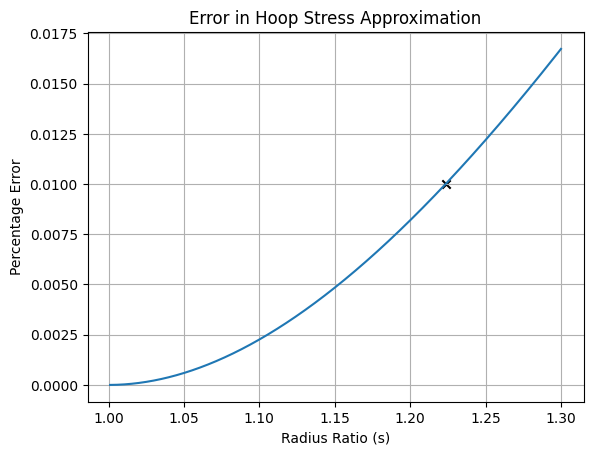

In [6]:
def find_s_ratio(P_i, r_i, threshold=0.01, n=3000):
    """Calculate the radius ratio 's' for which the hoop stress approximation error is less than threshold."""
    t = np.linspace(0.001, 0.3, n)  # thickness in meters
    r_o = r_i + t  # outer radius
    s = r_o / r_i  # radius ratio

    exact = lame_stress(r_i, r_o, P_i, 0)
    approx = thin_approx(r_i, r_o, P_i, 0)
    error = np.abs(exact - approx) / exact  # percentage error
    s_ratio = s[error < threshold]  # condition for acceptable error
    critical_s = s_ratio[-1] if len(s_ratio) > 0 else None
    print(f"Radius ratio 's' for which error is less than {threshold*100}%: {s_ratio}")
    print(f"Critical radius ratio 's' for acceptable error: {critical_s}")

    plt.plot(s, error)
    if len(s_ratio) > 0:
        plt.scatter(s_ratio[-1], threshold, marker='x', color='k',zorder=1)
    plt.xlabel('Radius Ratio (s)')
    plt.ylabel('Percentage Error')
    plt.title('Error in Hoop Stress Approximation')
    plt.grid()
    plt.show()
    return s_ratio

# Usage
P_i = 100  # Inner pressure in Pascals
r_i = 1    # Inner radius in meters

s_ratio = find_s_ratio(P_i, r_i)

## Error vs Pressure Difference Plot
**Inputs:**  
- `P_i`: Inner pressure  
- `r_i`: Inner radius  
- `s_ratio`: Array of radius ratios  
- `n`: Number of points (default 3000)  

**Outputs:**  
- Plots error in hoop stress approximation against pressure difference for selected radius ratios.

**Functionality:**  
- For several radius ratios, computes and plots the error in hoop stress approximation as a function of pressure difference.


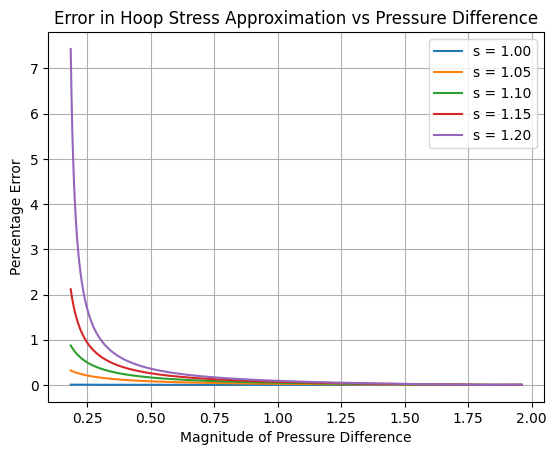

In [8]:
def error_against_pressure(P_i, r_i, s_ratio, n=3000):
    """Calculate the error in hoop stress approximation against pressure."""
    p_o = np.linspace(1, P_i*0.83, n)  # outer pressure in MPa
    p_magnitude = np.abs(P_i - p_o) / ((p_o + P_i)/2)  # magnitude of pressure difference

    for s in s_ratio[1::500]:  # Iterate through radius ratios
        r_o = s * r_i
        exact = lame_stress(r_i, r_o, P_i, p_o)
        approx = thin_approx(r_i, r_o, P_i, p_o)
        error = np.abs(exact - approx) / exact
        plt.plot(p_magnitude, error, label=f's = {s:.2f}')

    plt.xlabel('Magnitude of Pressure Difference')
    plt.ylabel('Percentage Error')
    plt.title('Error in Hoop Stress Approximation vs Pressure Difference')
    plt.legend()
    plt.grid()
    plt.show()

error_against_pressure(P_i, r_i, s_ratio)